# 改进的聚类和假阳性去除流程 - 完整测试版

这个Notebook提供了一个完整的测试框架，用于验证改进的聚类K值优化和假阳性去除策略。
您可以在此处填写您的真实数据路径和模型配置，在不修改源代码的情况下测试改进方案。

**流程说明：**
1. **配置部分** - 填写您的真实路径和参数
2. **导入模块** - 从您的pipeline脚本导入必要的函数
3. **改进的函数** - 新增的改进函数（K值优化改进、低置信度过滤）
4. **测试流程** - 运行改进的处理流程
5. **诊断分析** - 检查和分析结果


## 第一部分：配置您的路径和参数

⚠️ **请在下面的单元格中填写您的真实路径！**


In [12]:
# ====== 配置部分：填写您的真实路径 ======

# 【重要】请根据您的实际情况填写以下路径

CONFIG = {
    # ---- 参考域细胞路径 ----
    "reference": {
        "malignant_cells_dir": r"H:/limr/project/urine/rawdata/classification_model/UR_SingleCell/malignant",  # 参考域恶性细胞路径
        "benign_cells_dir": r"H:/limr/project/urine/rawdata/classification_model/UR_SingleCell/benign",          # 参考域良性细胞路径
    },
    
    # ---- 候选域图片路径 ----
    "candidate": {
        "positive_folder_path": r"H:\limr\project\urine\result\binary_infer\sample31\single_cell\test\pos",   # 阳性病例文件夹
        "negative_folder_path": r"H:\limr\project\urine\result\binary_infer\sample31\single_cell\test\neg",   # 阴性病例文件夹
    },
    
    # ---- 模型配置 ----
    "model": {
        "model_path": r"H:\\limr\\project\\urine\\result\\classification_model\\UR_SingleCell_seed300_v3\\train_val_models\\DenseNet161\\densenet161_fold_4.pth",  # 预训练模型路径
        "model_type": "DenseNet161",  # 或 "EfficientNetV2Large", "ConvNextLarge" 等
        "mean": [0.5918, 0.5688, 0.7202],  # 如果有归一化均值，填写这里；否则None
        "std": [0.2469, 0.2356, 0.1270],   # 如果有归一化标准差，填写这里；否则None
    },
    
    # ---- 输出路径 ----
    "output": {
        "base_save_dir": r"G:\04PhD\03Study\05SelfLearn\results\clustering\test_improved",  # 结果保存目录
    },
    
    # ---- 聚类参数 ----
    "clustering": {
        "reference_k": 10,           # 参考域簇数
        "max_candidate_k": 20,       # 候选域最大簇数
        "batch_size": 16,            # 批处理大小
        "num_workers": 0,            # 数据加载进程数
        "cell_size_weight": 1.0,     # 细胞大小权重
        "pca_dim": 32,               # PCA降维维度
        "feature_layer": "penultimate",  # 特征提取层
    },
    
    # ---- 关键参数：恶性簇索引 ----
    "malignant_ref_clusters": [8, 7, 1],  # 【必填】参考域中恶性簇的索引
    
    # ---- 改进参数：低置信度过滤 ----
    "improved_params": {
        "confidence_threshold": 0.45,  # 最小相似度阈值（可调整：0.3-0.6）
        "min_margin": 0.15,             # 恶性和良性相似度的最小差距（可调整：0.05-0.3）
    },
}

# 打印配置信息
print("="*60)
print("当前配置：")
print("="*60)
print(f"参考域恶性细胞: {CONFIG['reference']['malignant_cells_dir']}")
print(f"参考域良性细胞: {CONFIG['reference']['benign_cells_dir']}")
print(f"阳性样本文件夹: {CONFIG['candidate']['positive_folder_path']}")
print(f"阴性样本文件夹: {CONFIG['candidate']['negative_folder_path']}")
print(f"模型路径: {CONFIG['model']['model_path']}")
print(f"输出目录: {CONFIG['output']['base_save_dir']}")
print(f"恶性簇索引: {CONFIG['malignant_ref_clusters']}")
print("="*60)

当前配置：
参考域恶性细胞: H:/limr/project/urine/rawdata/classification_model/UR_SingleCell/malignant
参考域良性细胞: H:/limr/project/urine/rawdata/classification_model/UR_SingleCell/benign
阳性样本文件夹: H:\limr\project\urine\result\binary_infer\sample31\single_cell\test\pos
阴性样本文件夹: H:\limr\project\urine\result\binary_infer\sample31\single_cell\test\neg
模型路径: H:\\limr\\project\\urine\\result\\classification_model\\UR_SingleCell_seed300_v3\\train_val_models\\DenseNet161\\densenet161_fold_4.pth
输出目录: G:\04PhD\03Study\05SelfLearn\results\clustering\test_improved
恶性簇索引: [8, 7, 1]


## 第二部分：导入必要的库和模块


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import torch
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
# 设置随机种子
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


使用设备: cuda


In [3]:
# 导入自定义模块，确保路径正确
sys.path.insert(0, r'G:\04PhD\03Study\05SelfLearn\shilab-cluster-algorithm')
try:
    from cross_cluster_matching.models.models import get_model_and_transform
    from cross_cluster_matching.data.data_utils import (collect_reference_data, collect_image_paths, CellImageDataset, extract_patient_id)
    from cross_cluster_matching.models.feature_extractor import extract_features_with_cell_size
    from cross_cluster_matching.clustering.K_optimizer import optimize_k_for_candidate_clustering
    from cross_cluster_matching.clustering.matching_rule_application import (identify_matching_clusters, save_matched_cells, check_matching_rules)
    from cross_cluster_matching.visualization.visualization import (count_non_background_pixels, visualize_all_clusters_without_images, improved_visualize_clusters_with_images, analyze_cluster_composition, plot_similarity_heatmap)
    print('✓ 成功导入所有自定义模块')
except Exception as e:
    print(f'✗ 导入模块失败: {e}')
    print('  请检查模块路径是否正确')


✓ 成功导入所有自定义模块


## 第三部分：改进的函数
### 3.1 低置信度过滤函数
通过检查细胞与参考簇的相似度，识别可能的假阳性细胞。

In [4]:
def filter_low_confidence_cells(cell_sims, malignant_ref_clusters, benign_ref_clusters, confidence_threshold=0.4, min_margin=0.1):
    to_filter = []
    filter_reasons = {'low_sim': [], 'high_benign_sim': [], 'small_margin': []}
    for i in range(len(cell_sims)):
        max_malignant_sim = np.max(cell_sims[i, malignant_ref_clusters])
        max_benign_sim = np.max(cell_sims[i, benign_ref_clusters]) if len(benign_ref_clusters)>0 else 0
        if max_malignant_sim < confidence_threshold:
            to_filter.append(i)
            filter_reasons['low_sim'].append(i)
        elif abs(max_malignant_sim - max_benign_sim) < min_margin:
            to_filter.append(i)
            filter_reasons['small_margin'].append(i)
    low_conf_info = {
        'total_cells': len(cell_sims),
        'filtered_cells': len(to_filter),
        'filter_ratio': len(to_filter)/len(cell_sims) if len(cell_sims)>0 else 0,
        'reasons': filter_reasons,
        'avg_malignant_sim': np.mean(np.max(cell_sims[:, malignant_ref_clusters], axis=1)) if len(cell_sims)>0 else 0,
    }
    return to_filter, low_conf_info

def diagnose_similarity_distribution(cell_sims, malignant_ref_clusters, benign_ref_clusters, specimen_id='unknown', specimen_status='unknown'):
    diagnosis = {'specimen_id': specimen_id, 'specimen_status': specimen_status, 'total_cells': len(cell_sims)}
    malignant_sims = np.max(cell_sims[:, malignant_ref_clusters], axis=1) if len(cell_sims)>0 else np.array([])
    benign_sims = np.max(cell_sims[:, benign_ref_clusters], axis=1) if (len(cell_sims)>0 and len(benign_ref_clusters)>0) else np.zeros(len(malignant_sims))
    diagnosis['malignant_sim_mean'] = np.mean(malignant_sims) if malignant_sims.size>0 else 0
    diagnosis['malignant_sim_median'] = np.median(malignant_sims) if malignant_sims.size>0 else 0
    diagnosis['malignant_sim_min'] = np.min(malignant_sims) if malignant_sims.size>0 else 0
    diagnosis['malignant_sim_max'] = np.max(malignant_sims) if malignant_sims.size>0 else 0
    diagnosis['benign_sim_mean'] = np.mean(benign_sims) if benign_sims.size>0 else 0
    diagnosis['benign_sim_median'] = np.median(benign_sims) if benign_sims.size>0 else 0
    diagnosis['margin_mean'] = np.mean(malignant_sims - benign_sims) if malignant_sims.size>0 else 0
    diagnosis['margin_median'] = np.median(malignant_sims - benign_sims) if malignant_sims.size>0 else 0
    diagnosis['margin_min'] = np.min(malignant_sims - benign_sims) if malignant_sims.size>0 else 0
    diagnosis['cells_with_low_malignant_sim'] = np.sum(malignant_sims < 0.4) if malignant_sims.size>0 else 0
    diagnosis['cells_with_high_benign_sim'] = np.sum(benign_sims > 0.3) if benign_sims.size>0 else 0
    diagnosis['cells_with_small_margin'] = np.sum(np.abs(malignant_sims - benign_sims) < 0.15) if malignant_sims.size>0 else 0
    return diagnosis


### 3.2 改进的K值优化评分函数
加入恶性/良性的区分度指标以选择更合适的K值。

In [5]:
def compute_improved_cluster_quality_score(candidate_features, candidate_labels, kmeans, reference_centers, malignant_ref_clusters, benign_ref_clusters):
    n_clusters = kmeans.n_clusters
    similarity_matrix = cosine_similarity(kmeans.cluster_centers_, reference_centers)
    malignant_sim = similarity_matrix[:, malignant_ref_clusters].mean(axis=1) if len(malignant_ref_clusters)>0 else np.zeros(n_clusters)
    benign_sim = similarity_matrix[:, benign_ref_clusters].mean(axis=1) if len(benign_ref_clusters)>0 else np.zeros(n_clusters)
    malignant_oriented_clusters = np.sum(malignant_sim > benign_sim)
    separability = malignant_oriented_clusters / n_clusters if n_clusters>0 else 0
    inertia = kmeans.inertia_ if hasattr(kmeans, 'inertia_') else np.sum((candidate_features - kmeans.cluster_centers_[candidate_labels])**2)
    cohesion = 1.0 / (1.0 + inertia / max(1, len(candidate_features)))
    complexity_penalty = 1.0 - (n_clusters - 2) * 0.05
    weighted_score = (0.5 * separability + 0.35 * cohesion + 0.15 * complexity_penalty)
    scores_dict = {'separability': separability, 'cohesion': cohesion, 'complexity_penalty': complexity_penalty, 'weighted_score': weighted_score}
    return weighted_score, scores_dict


## 第四部分：测试单个病理片子的改进流程
运行改进的处理函数并输出诊断信息。

In [7]:
def process_specimen_with_improved_pipeline(specimen_folder, specimen_id, specimen_status, ref_results, model, transform, pca_model, config, device):
    print('' + '='*60)
    print(f'处理病理片子: {specimen_id} (Status: {specimen_status})')
    malignant_images_dir = os.path.join(specimen_folder, 'malignant_images')
    cand_paths = collect_image_paths(malignant_images_dir)
    if not cand_paths:
        print('⚠️  未找到恶性细胞图片，跳过')
        return None
    cand_sizes = np.log1p([count_non_background_pixels(p) for p in cand_paths])
    cand_loader = DataLoader(CellImageDataset(cand_paths, transform=transform, source_labels=[0]*len(cand_paths)), batch_size=config['clustering']['batch_size'], shuffle=False, num_workers=config['clustering']['num_workers'])
    cand_feats, _, cand_paths = extract_features_with_cell_size(model, cand_loader, device, cand_sizes, config['clustering']['feature_layer'], config['clustering']['cell_size_weight'])
    cand_norm = normalize(pca_model.transform(cand_feats))
    cell_sims = cosine_similarity(cand_norm, ref_results['cluster_centers'])
    diagnosis = diagnose_similarity_distribution(cell_sims, config['malignant_ref_clusters'], [i for i in range(ref_results['n_clusters']) if i not in config['malignant_ref_clusters']], specimen_id=specimen_id, specimen_status=specimen_status)
    print('【诊断信息】')
    print(f"  与恶性簇的相似度: mean={diagnosis['malignant_sim_mean']:.4f}, median={diagnosis['malignant_sim_median']:.4f}, min={diagnosis['malignant_sim_min']:.4f}")
    low_conf_indices, low_conf_info = filter_low_confidence_cells(cell_sims, config['malignant_ref_clusters'], [i for i in range(ref_results['n_clusters']) if i not in config['malignant_ref_clusters']], confidence_threshold=config['improved_params']['confidence_threshold'], min_margin=config['improved_params']['min_margin'])
    print('【低置信度过滤结果】')
    print(f"  过滤细胞数: {low_conf_info['filtered_cells']} / {low_conf_info['total_cells']} ({low_conf_info['filter_ratio']*100:.1f}%)")
    cluster_info = None
    if len(cand_norm) >= 32:
        k_scores = []
        for k in range(2, min(7, len(cand_norm)//3)):
            try:
                kmeans = KMeans(n_clusters=k, random_state=42, max_iter=300)
                labels = kmeans.fit_predict(cand_norm)
                if len(np.unique(labels)) == k:
                    score, score_dict = compute_improved_cluster_quality_score(cand_norm, labels, kmeans, ref_results['cluster_centers'], config['malignant_ref_clusters'], [i for i in range(ref_results['n_clusters']) if i not in config['malignant_ref_clusters']])
                    k_scores.append((k,score,score_dict))
            except:
                continue
        if k_scores:
            best_k, best_score, best_scores = max(k_scores, key=lambda x: x[1])
            print(f'  ✓ 最优K值: {best_k} (Score={best_score:.4f})')
            kmeans_best = KMeans(n_clusters=best_k, random_state=42)
            cand_labels = kmeans_best.fit_predict(cand_norm)
            cluster_info = {'best_k': best_k, 'labels': cand_labels, 'centers': kmeans_best.cluster_centers_, 'k_scores': k_scores}
    result = {'specimen_id': specimen_id, 'specimen_status': specimen_status, 'total_cells': len(cand_norm), 'diagnosis': diagnosis, 'low_confidence_filter': low_conf_info, 'cluster_info': cluster_info, 'cell_similarities': cell_sims}
    return result


## 第五部分：可视化结果
生成诊断图表分析过滤效果。

In [8]:
def visualize_filtering_results(result, save_dir=None):
    fig, axes = plt.subplots(2,2, figsize=(14,10))
    fig.suptitle(f"病理片子 {result['specimen_id']} - 改进流程诊断", fontsize=14, fontweight='bold')
    cell_sims = result['cell_similarities']
    low_conf = result['low_confidence_filter']
    malignant_sims = np.max(cell_sims[:, CONFIG['malignant_ref_clusters']], axis=1) if cell_sims.size>0 else np.array([])
    ax = axes[0,0]
    ax.hist(malignant_sims, bins=30, alpha=0.7, color='red', edgecolor='black')
    ax.axvline(CONFIG['improved_params']['confidence_threshold'], color='blue', linestyle='--', linewidth=2, label=f"过滤阈值={CONFIG['improved_params']['confidence_threshold']}")
    ax.set_title('恶性相似度分布')
    ax.legend()
    benign_sims = np.max(cell_sims[:, [i for i in range(cell_sims.shape[1]) if i not in CONFIG['malignant_ref_clusters']]], axis=1) if cell_sims.size>0 else np.array([])
    margin = malignant_sims - benign_sims if malignant_sims.size>0 else np.array([])
    ax = axes[0,1]
    ax.hist(margin, bins=30, alpha=0.7, color='green', edgecolor='black')
    ax.axvline(CONFIG['improved_params']['min_margin'], color='blue', linestyle='--', linewidth=2, label=f"最小差距={CONFIG['improved_params']['min_margin']}")
    ax.set_title('恶恶性相似度差距分布')
    ax.legend()
    ax = axes[1,0]
    labels = ['保留','过滤']
    sizes = [low_conf['total_cells'] - low_conf['filtered_cells'], low_conf['filtered_cells']]
    ax.pie(sizes, labels=labels, autopct='%1.1f%%')
    ax.set_title(f"过滤结果 (总计: {low_conf['total_cells']}个细胞)")
    ax = axes[1,1]
    reasons = ['与恶性簇\n相似度低', '恶恶性\n差距小']
    counts = [len(low_conf['reasons']['low_sim']), len(low_conf['reasons']['small_margin'])]
    ax.bar(reasons, counts)
    ax.set_title('过滤原因分析')
    for i, count in enumerate(counts):
        ax.text(i, count+0.5, str(count), ha='center')
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{result['specimen_id']}_filtering_analysis.png")
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'✓ 已保存可视化: {save_path}')
    plt.show()


## 第六部分：运行完整的改进流程
加载参考域、模型，处理若干候选病理片子并保存结果。

In [15]:
os.makedirs(CONFIG['output']['base_save_dir'], exist_ok=True)
print('=*'*35)
print('第1步：加载参考域数据和进行聚类')
ref_paths, ref_sources = collect_reference_data(CONFIG['reference']['malignant_cells_dir'], CONFIG['reference']['benign_cells_dir'])
print(f'✓ 参考域数据：恶性={ref_sources.count(1)}, 良性={ref_sources.count(0)}')
print('加载预训练模型...')
model, transform, _ = get_model_and_transform(CONFIG['model']['model_type'], device, CONFIG['model']['model_path'], mean=CONFIG['model']['mean'], std=CONFIG['model']['std'])
print(f"✓ 模型已加载：{CONFIG['model']['model_type']}")
ref_sizes = np.log1p([count_non_background_pixels(p) for p in tqdm(ref_paths, desc='计算参考域大小')])
ref_loader = DataLoader(CellImageDataset(ref_paths, transform=transform, source_labels=ref_sources), batch_size=CONFIG['clustering']['batch_size'], shuffle=False, num_workers=CONFIG['clustering']['num_workers'])
ref_feats, ref_sources, ref_paths = extract_features_with_cell_size(model, ref_loader, device, ref_sizes, CONFIG['clustering']['feature_layer'], CONFIG['clustering']['cell_size_weight'])
print(f'✓ 参考域特征提取完成，维度: {ref_feats.shape}')
pca = PCA(n_components=min(CONFIG['clustering']['pca_dim'], ref_feats.shape[0], ref_feats.shape[1]))
ref_norm = normalize(pca.fit_transform(ref_feats))
kmeans_ref = KMeans(n_clusters=CONFIG['clustering']['reference_k'], random_state=42)
ref_labels = kmeans_ref.fit_predict(ref_norm)
ref_results = {'features': ref_norm, 'labels': ref_labels, 'source_labels': ref_sources, 'cluster_centers': kmeans_ref.cluster_centers_, 'n_clusters': CONFIG['clustering']['reference_k'], 'pca': pca}
print(f"✓ 参考域聚类完成，K={CONFIG['clustering']['reference_k']}")

=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
第1步：加载参考域数据和进行聚类
✓ 参考域数据：恶性=0, 良性=0
加载预训练模型...
DenseNet161模型权重加载成功！
✓ 模型已加载：DenseNet161


提取特征: 100%|██████████| 125/125 [00:06<00:00, 19.17it/s]


✓ 参考域特征提取完成，维度: (1997, 2209)
✓ 参考域聚类完成，K=10


第2步：处理候选域病理片子
✓ 找到 2 个病理片子
【1/2】处理 SH_xxqin_p1 (positive)...
处理病理片子: SH_xxqin_p1 (Status: positive)


提取特征: 100%|██████████| 353/353 [00:14<00:00, 23.72it/s]


【诊断信息】
  与恶性簇的相似度: mean=0.7557, median=0.7629, min=0.3183
【低置信度过滤结果】
  过滤细胞数: 44 / 5644 (0.8%)
  ✓ 最优K值: 2 (Score=0.9361)
✓ 已保存可视化: G:\04PhD\03Study\05SelfLearn\results\clustering\test_improved\SH_xxqin_p1\SH_xxqin_p1_filtering_analysis.png


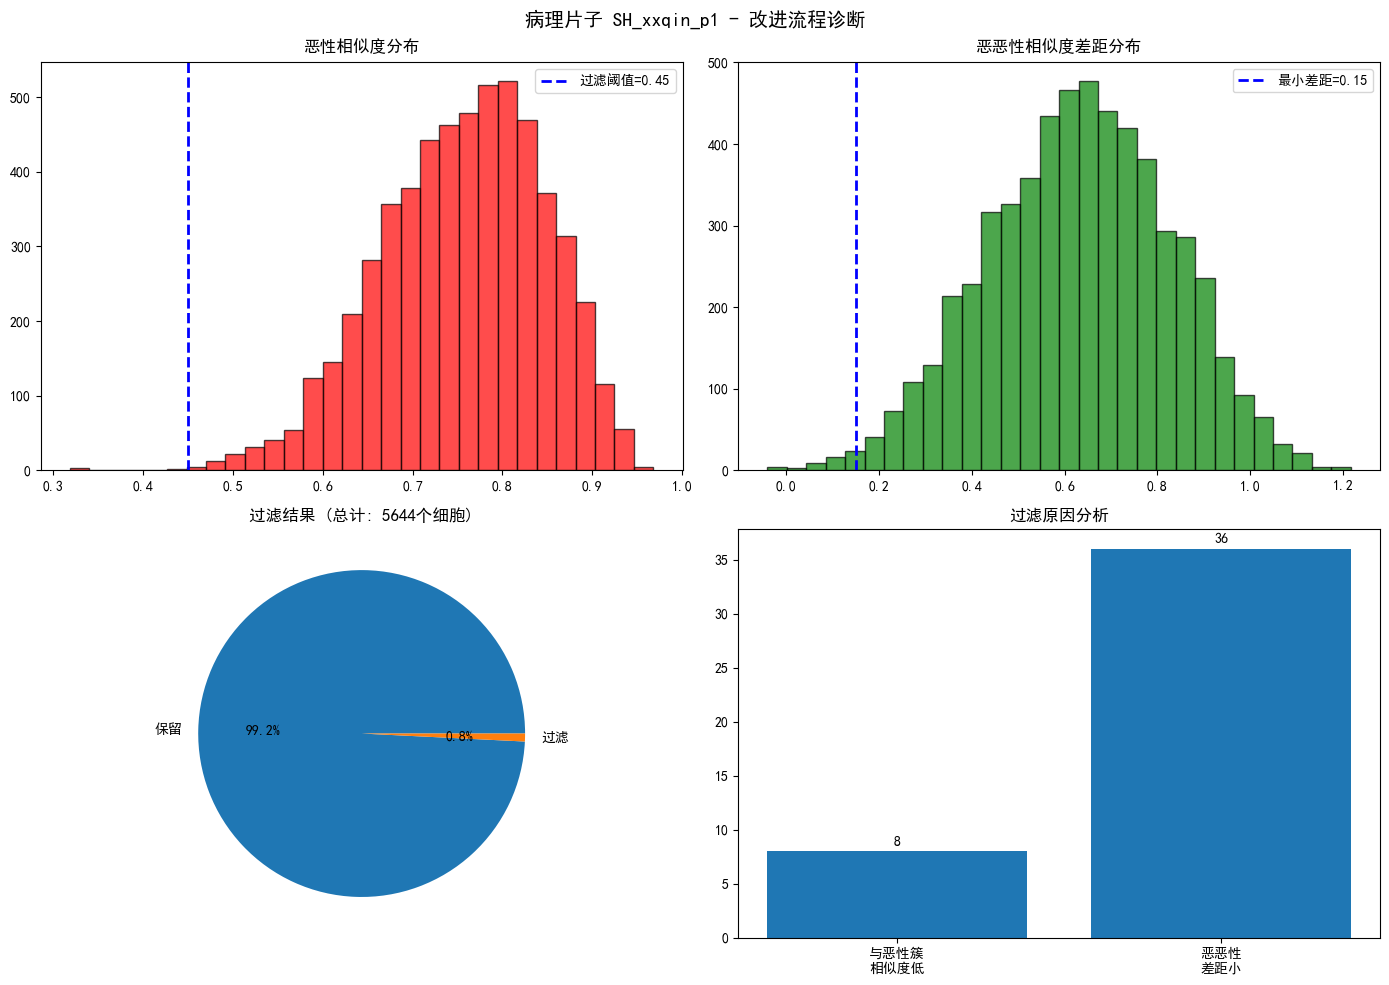

【2/2】处理 SH_56913 (negative)...
处理病理片子: SH_56913 (Status: negative)


提取特征: 100%|██████████| 5/5 [00:00<00:00,  9.92it/s]


【诊断信息】
  与恶性簇的相似度: mean=0.6620, median=0.6606, min=0.4451
【低置信度过滤结果】
  过滤细胞数: 1 / 67 (1.5%)
  ✓ 最优K值: 2 (Score=0.9217)
✓ 已保存可视化: G:\04PhD\03Study\05SelfLearn\results\clustering\test_improved\SH_56913\SH_56913_filtering_analysis.png


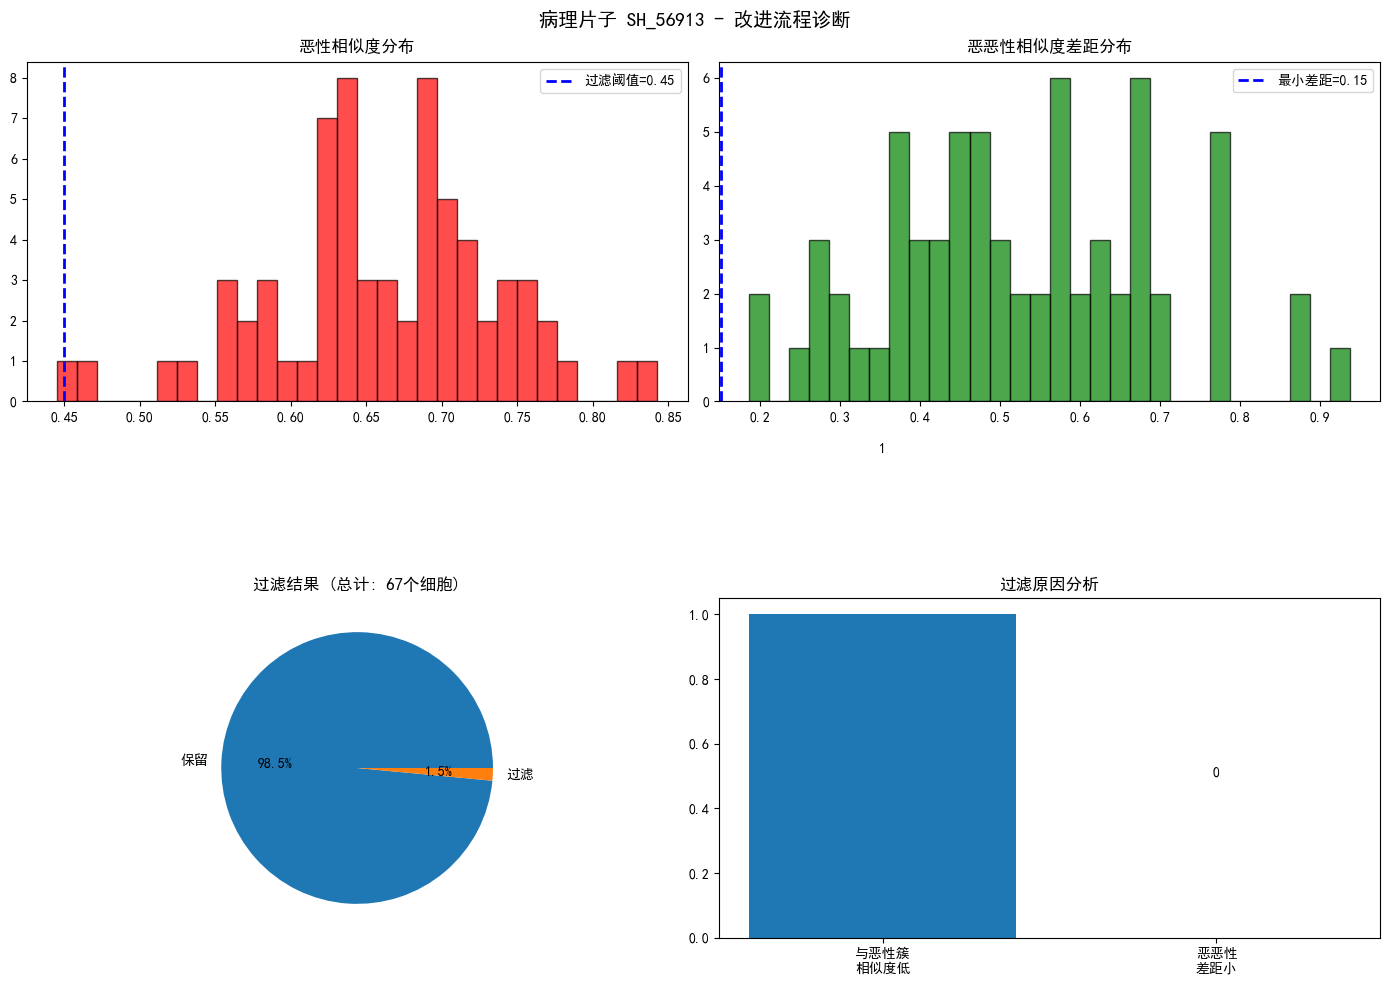

✓ 处理完成，共处理 2 个样本


In [16]:
print('' + '='*60)
print('第2步：处理候选域病理片子')
patient_folders = []
if os.path.exists(CONFIG['candidate']['positive_folder_path']):
    patient_folders.extend([(entry.path,'positive') for entry in os.scandir(CONFIG['candidate']['positive_folder_path']) if entry.is_dir()])
if os.path.exists(CONFIG['candidate']['negative_folder_path']):
    patient_folders.extend([(entry.path,'negative') for entry in os.scandir(CONFIG['candidate']['negative_folder_path']) if entry.is_dir()])
print(f'✓ 找到 {len(patient_folders)} 个病理片子')
results_list = []
max_specimens = min(5, len(patient_folders))
for i, (folder, status) in enumerate(patient_folders[:max_specimens]):
    specimen_id = extract_patient_id(folder)
    print(f'【{i+1}/{max_specimens}】处理 {specimen_id} ({status})...')
    result = process_specimen_with_improved_pipeline(folder, specimen_id, status, ref_results, model, transform, pca, CONFIG, device)
    if result is not None:
        results_list.append(result)
        sample_save_dir = os.path.join(CONFIG['output']['base_save_dir'], specimen_id)
        os.makedirs(sample_save_dir, exist_ok=True)
        diag_df = pd.DataFrame([result['diagnosis']])
        diag_df.to_csv(os.path.join(sample_save_dir, 'diagnosis.csv'), index=False, encoding='utf-8-sig')
        filter_df = pd.DataFrame([{'specimen_id': result['specimen_id'], 'specimen_status': result['specimen_status'], 'total_cells': result['low_confidence_filter']['total_cells'], 'filtered_cells': result['low_confidence_filter']['filtered_cells'], 'filter_ratio': result['low_confidence_filter']['filter_ratio']}])
        filter_df.to_csv(os.path.join(sample_save_dir, 'filtering_stats.csv'), index=False, encoding='utf-8-sig')
        visualize_filtering_results(result, save_dir=sample_save_dir)
print(f'✓ 处理完成，共处理 {len(results_list)} 个样本')


In [17]:
print('' + '='*60)
print('第3步：统计和分析结果')
summary_data = []
for result in results_list:
    summary_data.append({'Specimen ID': result['specimen_id'], 'Status': result['specimen_status'], 'Total Cells': result['total_cells'], 'Malignant Sim (Mean)': f"{result['diagnosis']['malignant_sim_mean']:.4f}", 'Benign Sim (Mean)': f"{result['diagnosis']['benign_sim_mean']:.4f}", 'Margin (Mean)': f"{result['diagnosis']['margin_mean']:.4f}", 'Filtered Cells': result['low_confidence_filter']['filtered_cells'], 'Filter Ratio': f"{result['low_confidence_filter']['filter_ratio']*100:.1f}%"})
summary_df = pd.DataFrame(summary_data)
print('【处理结果汇总】')
print(summary_df.to_string(index=False))
summary_save_path = os.path.join(CONFIG['output']['base_save_dir'], 'improved_pipeline_summary.csv')
summary_df.to_csv(summary_save_path, index=False, encoding='utf-8-sig')
print(f'✓ 汇总结果已保存: {summary_save_path}')


第3步：统计和分析结果
【处理结果汇总】
Specimen ID   Status  Total Cells Malignant Sim (Mean) Benign Sim (Mean) Margin (Mean)  Filtered Cells Filter Ratio
SH_xxqin_p1 positive         5644               0.7557            0.1244        0.6313              44         0.8%
   SH_56913 negative           67               0.6620            0.1363        0.5257               1         1.5%
✓ 汇总结果已保存: G:\04PhD\03Study\05SelfLearn\results\clustering\test_improved\improved_pipeline_summary.csv


In [18]:
# 参数灵敏度分析 (使用第一个结果)
print('' + '='*60)
print('参数灵敏度分析')
if results_list:
    test_result = results_list[0]
    cell_sims = test_result['cell_similarities']
    print(f"样本: {test_result['specimen_id']} ({test_result['specimen_status']})")
    print(f"总细胞数: {len(cell_sims)}")
    print(f"{'Threshold':<12} {'Filtered':<12} {'Ratio':<12} {'说明'}")
    print('-'*60)
    for threshold in [0.25,0.30,0.35,0.40,0.45,0.50,0.55]:
        low_conf_indices, info = filter_low_confidence_cells(cell_sims, CONFIG['malignant_ref_clusters'], [i for i in range(cell_sims.shape[1]) if i not in CONFIG['malignant_ref_clusters']], confidence_threshold=threshold, min_margin=CONFIG['improved_params']['min_margin'])
        ratio = info['filter_ratio']*100
        if ratio < 10:
            note = '过滤较少，可能漏掉假阳性'
        elif ratio > 50:
            note = '过滤过多，可能误删真阳性'
        else:
            note = '适度过滤'
        marker = ' ← 当前设置' if abs(threshold - CONFIG['improved_params']['confidence_threshold'])<1e-6 else ''
        print(f"{threshold:<12.2f} {info['filtered_cells']:<12} {ratio:<12.1f}% {note}{marker}")
print('✓ 灵敏度分析完成')


参数灵敏度分析
样本: SH_xxqin_p1 (positive)
总细胞数: 5644
Threshold    Filtered     Ratio        说明
------------------------------------------------------------
0.25         40           0.7         % 过滤较少，可能漏掉假阳性
0.30         40           0.7         % 过滤较少，可能漏掉假阳性
0.35         41           0.7         % 过滤较少，可能漏掉假阳性
0.40         42           0.7         % 过滤较少，可能漏掉假阳性
0.45         44           0.8         % 过滤较少，可能漏掉假阳性 ← 当前设置
0.50         63           1.1         % 过滤较少，可能漏掉假阳性
0.55         134          2.4         % 过滤较少，可能漏掉假阳性
✓ 灵敏度分析完成
